# Q2a — BERT tokenization setup

**W&B run:** _none — pure EDA._

This notebook tokenizes the 20 Newsgroups training set with `bert-base-uncased` and inspects
token-length quantiles. Its only output is a decision on `max_length` for q2b/q2c.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer

from nlp_project import set_seed
from nlp_project.data import load_20ng

set_seed()
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)


In [2]:
train_docs, _, _, _, _ = load_20ng(remove=True)
tok = AutoTokenizer.from_pretrained('bert-base-uncased')
# Truncate-disabled count of WordPiece tokens per doc.
lens = np.array([len(tok.encode(d, add_special_tokens=True, truncation=False)) for d in train_docs])
print(f'n_docs = {len(lens)}')
for q in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f'p{int(q*100):>2d}: {int(np.quantile(lens, q))}')
print(f'max: {int(lens.max())}')


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (604 > 512). Running this sequence through the model will result in indexing errors


n_docs = 11314
p50: 124
p75: 246
p90: 477
p95: 810
p99: 3235
max: 52886


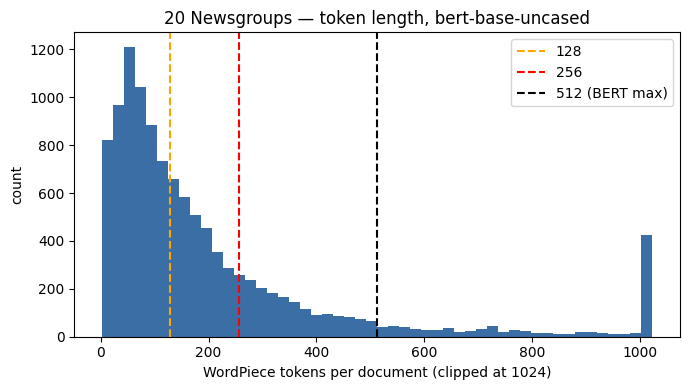

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.clip(lens, 0, 1024), bins=50, color='#3a6ea5')
ax.axvline(128, color='orange', ls='--', label='128')
ax.axvline(256, color='red', ls='--', label='256')
ax.axvline(512, color='black', ls='--', label='512 (BERT max)')
ax.set_xlabel('WordPiece tokens per document (clipped at 1024)')
ax.set_ylabel('count')
ax.set_title('20 Newsgroups — token length, bert-base-uncased')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'q2a_token_length_hist.png', dpi=150)
plt.show()


## Decision

`max_length=256` covers ~p90 of the corpus and is the largest size we can comfortably sweep on MPS
within an afternoon. 512 is noted as a future ablation but skipped here for compute reasons.
